# Esercitazione: Analisi di Clustering su Dataset di Vini sfruttando PCA

## Introduzione
Questa esercitazione esplora tecniche di apprendimento non supervisionato applicate all'analisi dei vini. Combiniamo l'analisi delle componenti principali (PCA) con algoritmi di clustering per identificare modelli naturali nelle caratteristiche chimiche dei vini, ottimizzando i risultati attraverso l'analisi del coefficiente di Silhouette o algoritmo Elbow.

## Obiettivi
1. Applicare la PCA per ridurre la dimensionalità e identificare le componenti che spiegano la maggior parte della varianza nei dati
2. Determinare il numero ottimale di cluster utilizzando il coefficiente di Silhouette o Elbow
3. Eseguire il clustering K-means sulle componenti principali e interpretare i risultati
4. Caratterizzare i cluster identificati in termini delle feature originali del vino

In questo notebook non vogliamo costruire un modello supervisionato per predire una classe.

## Nota sulla pipeline ML

In una pipeline supervisionata completa dovremmo separare i dati in training e test set prima delle trasformazioni che apprendono parametri dai dati.

Qui però non stiamo addestrando un modello predittivo da valutare su dati futuri.  
Stiamo usando PCA e clustering come strumenti esplorativi.

Per questo motivo non eseguiamo train/test split: analizziamo l'intero dataset per descriverne la struttura.

## Dataset
Il dataset contiene misurazioni di 13 attributi chimici di diversi vini italiani. Questi attributi includono il contenuto di alcol, acido malico, cenere, alcalinità della cenere, magnesio, fenoli totali, flavonoidi, fenoli non flavonoidi, proantocianidine, intensità del colore, tonalità, OD280/OD315 e prolina. Il dataset è spesso utilizzato per il riconoscimento di pattern e la classificazione in machine learning, ma in questa esercitazione lo utilizzeremo per tecniche non supervisionate.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [16]:
df = pd.read_csv("datasets/wine-clustering.csv")
df.head(10)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [4]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
df.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

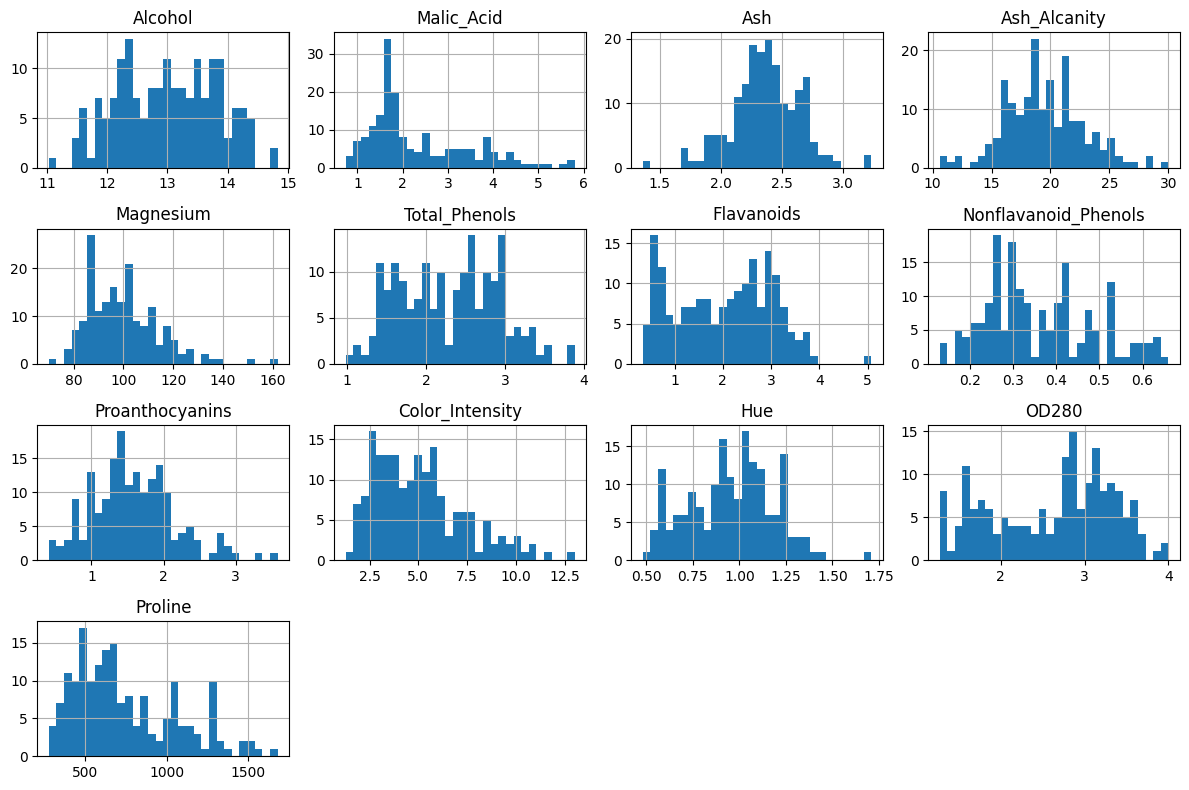

In [6]:
df.hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

### Cosa osserviamo nell'EDA

Questa prima analisi serve a capire la forma generale del dataset.

Controlliamo:

- numero di campioni e feature;
- tipo delle variabili;
- presenza di valori mancanti;
- range e distribuzione delle feature;
- possibili differenze di scala tra le variabili.

Queste informazioni sono importanti perché PCA e K-means lavorano su distanze e varianze: feature con scale molto diverse possono dominare l'analisi.

<Axes: >

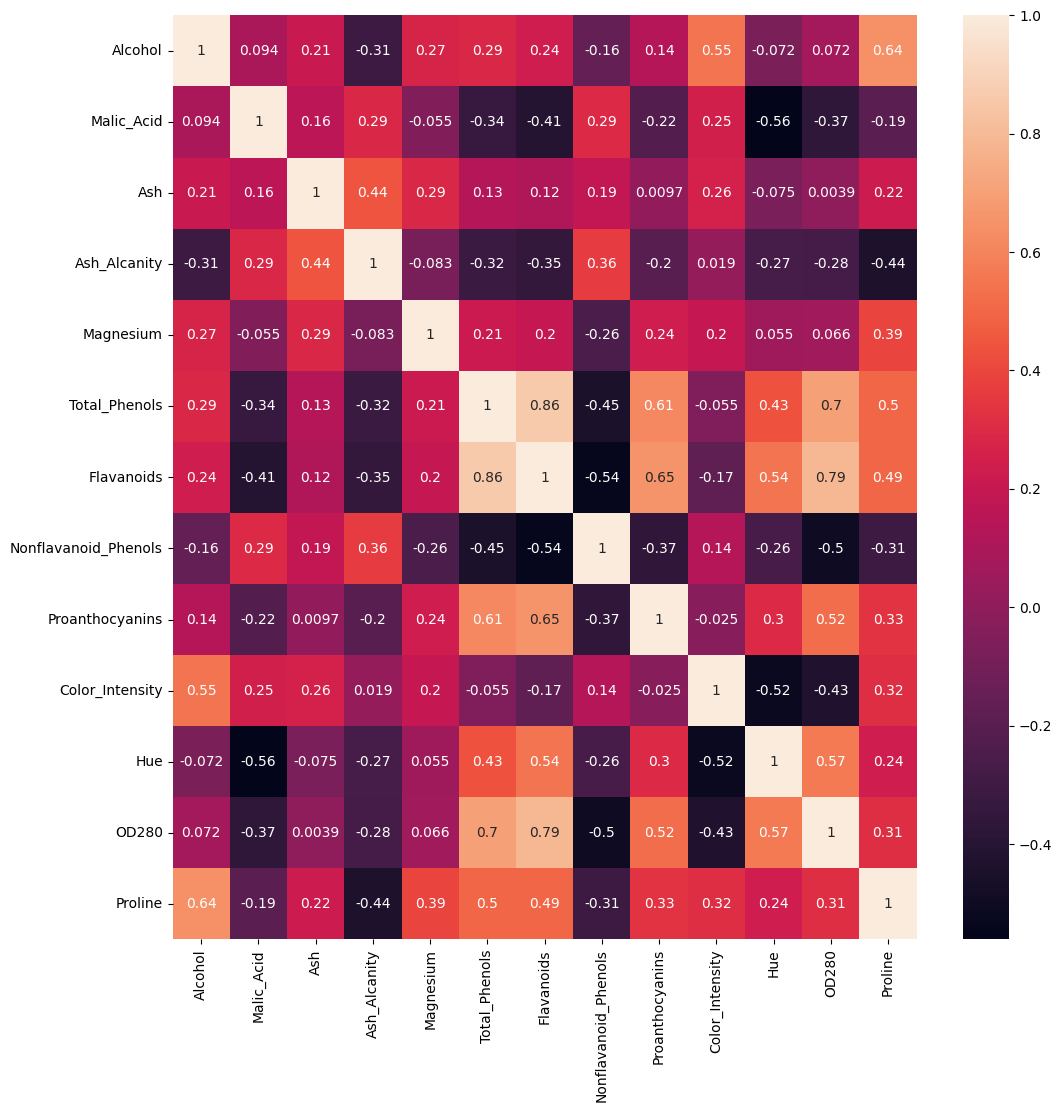

In [7]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(numeric_only=True),annot=True)

### Interpretazione della correlazione

La heatmap mostra che alcune feature sono fortemente correlate tra loro.

Questo suggerisce la presenza di ridondanza informativa: alcune variabili descrivono aspetti simili del vino.

In questo contesto, la PCA è utile perché può comprimere parte di questa informazione ridondante in un numero minore di componenti principali.

### Perché passiamo direttamente allo scaling

Nella pipeline supervisionata completa, tra EDA e scaling potremmo svolgere altri passaggi: split train/test, cleaning delle feature e analisi feature-target.

Qui li saltiamo perché l'obiettivo non è predire un target, ma studiare la struttura dei dati.

Lo scaling è invece necessario: PCA e K-means sono sensibili alla scala delle feature.

In [17]:
scaler=StandardScaler()
scaler.fit(df)
data_scaled=scaler.transform(df)

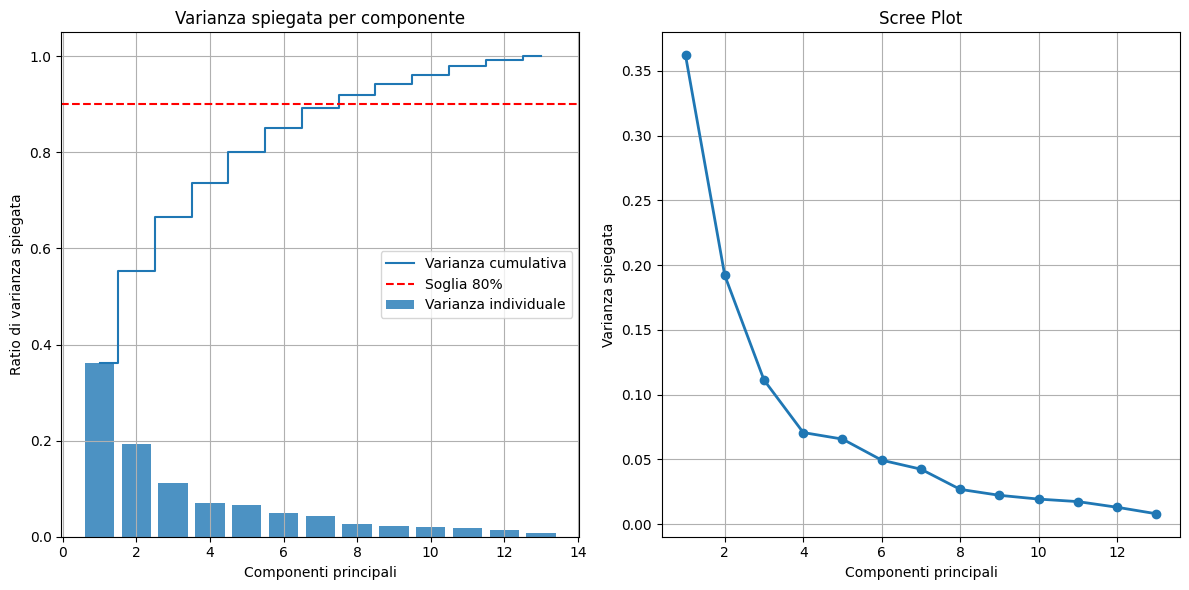

Numero di componenti che spiegano almeno il 90% della varianza: 8
Percentuale esatta di varianza spiegata con 8 componenti: 92.02%


In [20]:
from sklearn.decomposition import PCA
pca = PCA()
pca_result = pca.fit_transform(data_scaled)

# Analisi della varianza spiegata
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Creazione di un dataframe per i risultati della PCA
pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(len(df.columns))])

# Visualizzazione della varianza spiegata
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.8, label='Varianza individuale')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Varianza cumulativa')
plt.axhline(y=0.9, color='r', linestyle='--', label='Soglia 80%')
plt.ylabel('Ratio di varianza spiegata')
plt.xlabel('Componenti principali')
plt.title('Varianza spiegata per componente')
plt.legend(loc='best')
plt.grid(True)

# Scree plot - un altro modo per visualizzare la varianza spiegata
plt.subplot(1, 2, 2)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'o-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Componenti principali')
plt.ylabel('Varianza spiegata')
plt.grid(True)
plt.tight_layout()
plt.show()

# Determinare il numero di componenti che spiegano almeno l'80% della varianza
n_components = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Numero di componenti che spiegano almeno il 90% della varianza: {n_components}")
print(f"Percentuale esatta di varianza spiegata con {n_components} componenti: {cumulative_variance[n_components-1]*100:.2f}%")

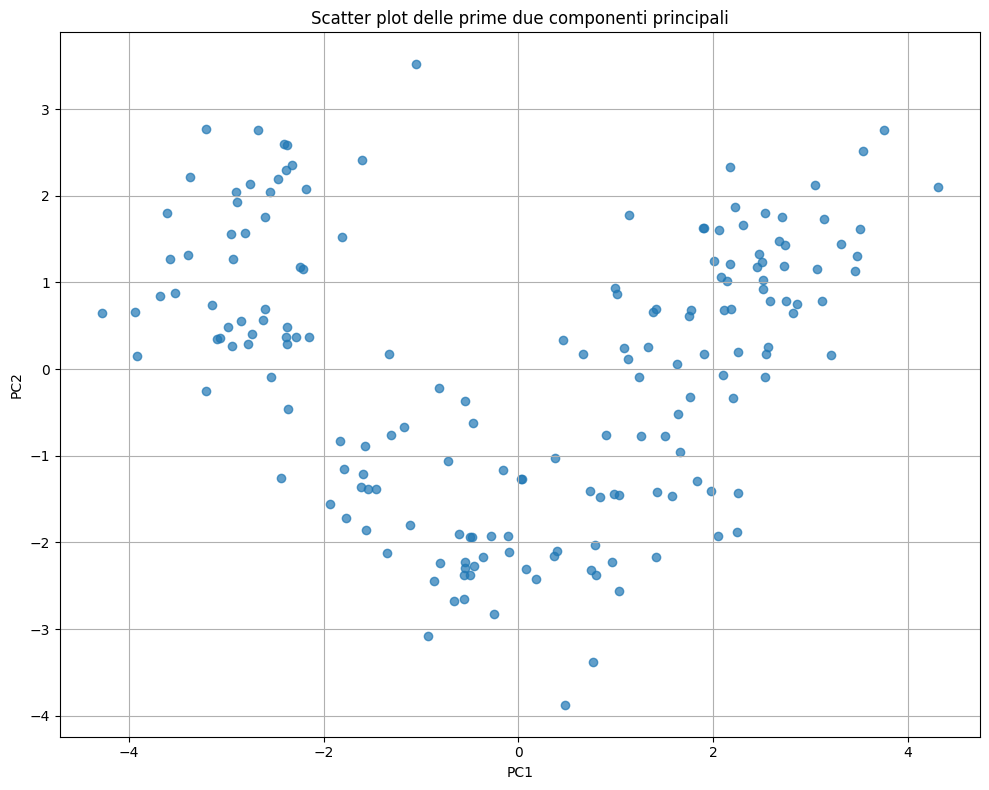

In [21]:
# Riduciamo la dimensionalità al numero di componenti selezionate
pca_reduced = PCA(n_components=n_components)
principal_components = pca_reduced.fit_transform(data_scaled)

# Creazione di un DataFrame con le componenti principali
pc_df = pd.DataFrame(
    data=principal_components,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

# Visualizzazione delle prime due componenti principali
plt.figure(figsize=(10, 8))
plt.scatter(pc_df['PC1'], pc_df['PC2'], alpha=0.7)
plt.title('Scatter plot delle prime due componenti principali')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()

### Cosa ci dice lo spazio PCA

Il grafico mostra i campioni proiettati sulle prime due componenti principali.

Se nello spazio PCA osserviamo gruppi separati, questo suggerisce che il dataset potrebbe contenere cluster naturali.

Tuttavia, la PCA è solo una proiezione: eventuali sovrapposizioni in 2D non implicano necessariamente assenza di struttura nelle dimensioni successive.

k=2 - Inerzia: 1474.45, Silhouette: 0.2930
k=3 - Inerzia: 1094.38, Silhouette: 0.3150
k=4 - Inerzia: 993.78, Silhouette: 0.2846
k=5 - Inerzia: 927.94, Silhouette: 0.2683
k=6 - Inerzia: 868.87, Silhouette: 0.2103
k=7 - Inerzia: 815.64, Silhouette: 0.1918
k=8 - Inerzia: 753.51, Silhouette: 0.1788
k=9 - Inerzia: 712.84, Silhouette: 0.1682
k=10 - Inerzia: 681.96, Silhouette: 0.1712


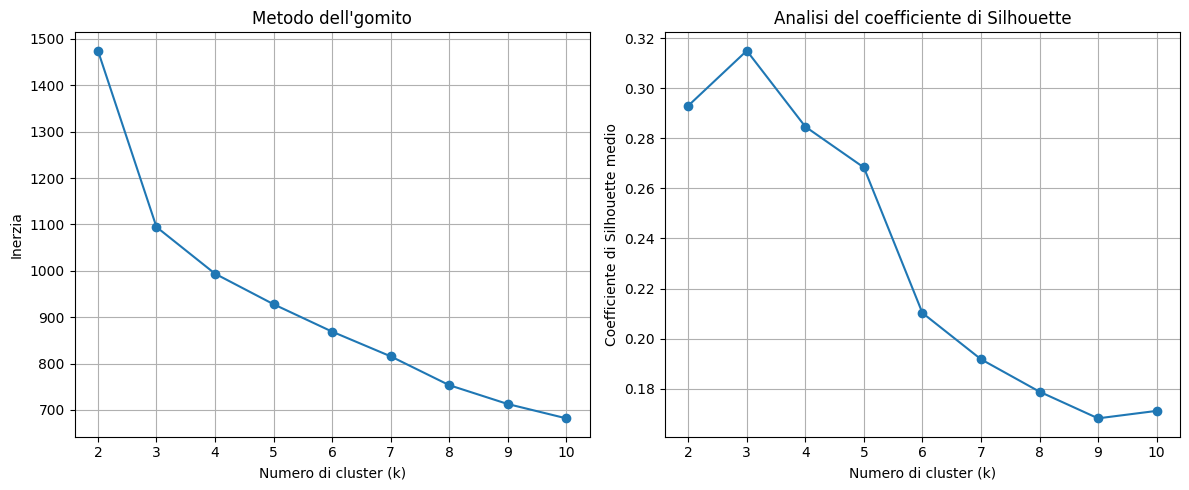

In [22]:
from sklearn.metrics import silhouette_score, silhouette_samples
# Calcolo dell'inerzia (Elbow Method) e del coefficiente di Silhouette per diversi valori di k
range_n_clusters = range(2, 11)
inertia_list = []
silhouette_avg_list = []

for k in range_n_clusters:
    # Addestramento del modello KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pc_df)
    
    # Salvataggio dell'inerzia
    inertia_list.append(kmeans.inertia_)
    
    # Calcolo del coefficiente di Silhouette
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(pc_df, cluster_labels)
    silhouette_avg_list.append(silhouette_avg)
    
    print(f"k={k} - Inerzia: {kmeans.inertia_:.2f}, Silhouette: {silhouette_avg:.4f}")

# Visualizzazione del metodo dell'gomito
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia_list, marker="o")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Inerzia")
plt.title("Metodo dell'gomito")
plt.grid(True)

# Visualizzazione del coefficiente di Silhouette
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_avg_list, marker="o")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Coefficiente di Silhouette medio")
plt.title("Analisi del coefficiente di Silhouette")
plt.grid(True)

plt.tight_layout()
plt.show()

### Scelta del numero di cluster

Il metodo del gomito osserva la riduzione dell'inertia al crescere di `k`.  
La silhouette misura quanto i cluster sono compatti e separati.

Se i due criteri non indicano esattamente lo stesso valore, la scelta di `k` va interpretata in modo critico.

In questo notebook scegliamo `k = 3` come compromesso ragionevole da usare per l'analisi successiva.

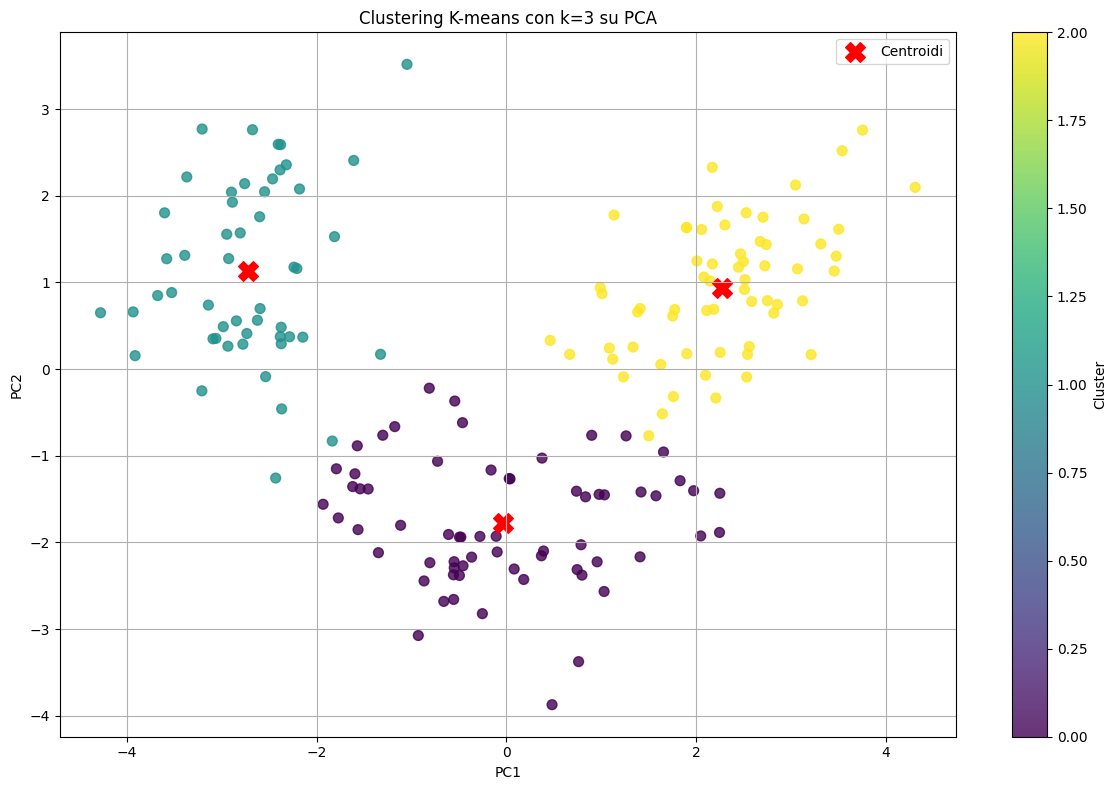

In [23]:
# Esecuzione del clustering K-means con il numero ottimale di cluster
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels_final = kmeans_final.fit_predict(principal_components)

# Aggiungiamo i cluster al DataFrame originale e al DataFrame delle componenti principali
df['Cluster'] = cluster_labels_final
pc_df['Cluster'] = cluster_labels_final

# Visualizzazione dei cluster nelle prime due componenti principali
plt.figure(figsize=(12, 8))
scatter = plt.scatter(pc_df['PC1'], pc_df['PC2'], c=pc_df['Cluster'], 
                     cmap='viridis', s=50, alpha=0.8)
plt.title(f'Clustering K-means con k={optimal_k} su PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.colorbar(scatter, label='Cluster')

# Aggiungiamo i centroidi
centroids = kmeans_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X', c='red', label='Centroidi')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretazione del clustering

Il grafico mostra i cluster trovati da K-means nello spazio delle componenti principali.

K-means assegna ogni campione al centroide più vicino.  
I cluster visualizzati rappresentano gruppi di vini simili rispetto alle combinazioni principali delle feature chimiche.

I centroidi indicano il centro medio di ciascun gruppo nello spazio PCA.

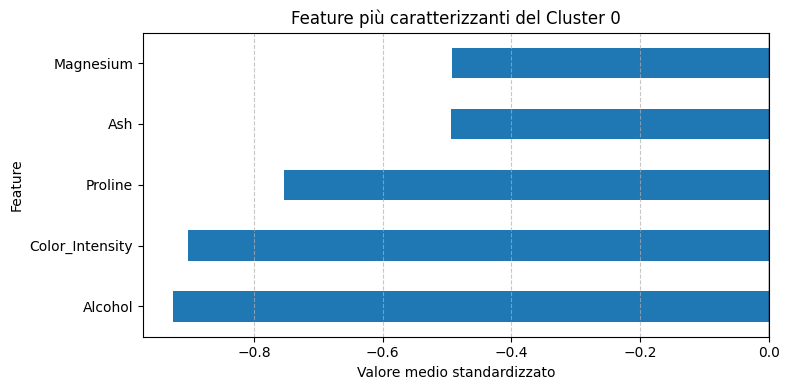

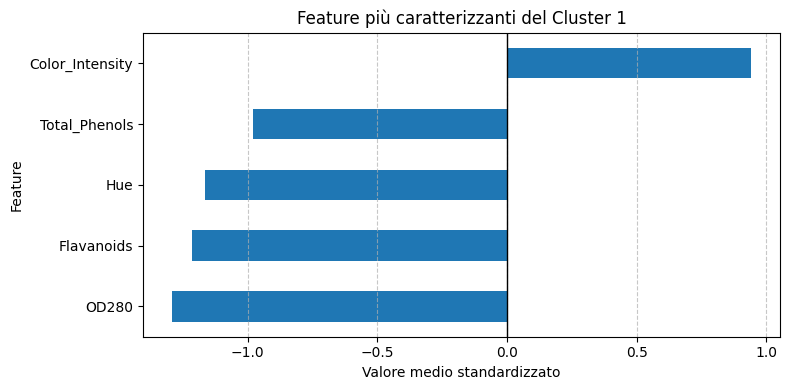

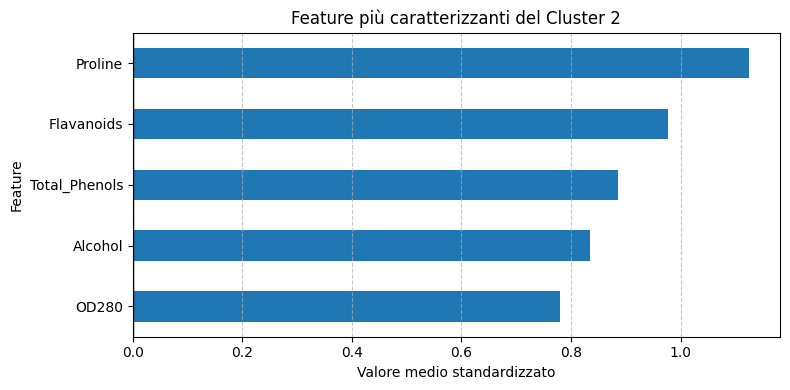

In [28]:
# Profilo medio standardizzato dei cluster
cluster_profile = df_scaled.groupby('Cluster').mean()

# Numero di feature più caratterizzanti da mostrare per ogni cluster
top_n = 5

for cluster_id in cluster_profile.index:
    
    # Profilo medio del cluster
    profile = cluster_profile.loc[cluster_id]
    
    # Selezioniamo le feature più lontane da 0, cioè più diverse dalla media del dataset
    top_features = profile.abs().sort_values(ascending=False).head(top_n).index
    
    # Recuperiamo i valori reali, con segno positivo/negativo
    values = profile[top_features].sort_values()
    
    # Grafico orizzontale
    plt.figure(figsize=(8, 4))
    values.plot(kind='barh')
    
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f'Feature più caratterizzanti del Cluster {cluster_id}')
    plt.xlabel('Valore medio standardizzato')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Interpretazione dei profili dei cluster

I grafici mostrano, per ciascun cluster, le feature che si discostano di più dalla media del dataset.

Valori positivi indicano feature sopra la media; valori negativi indicano feature sotto la media. In entrambi i casi, più il valore è lontano da zero, più quella feature caratterizza il cluster.

- **Cluster 0**: valori sotto la media per `Alcohol`, `Color_Intensity`, `Proline`, `Ash` e `Magnesium`.
- **Cluster 1**: `Color_Intensity` sopra la media, ma `OD280`, `Flavanoids`, `Hue` e `Total_Phenols` sotto la media.
- **Cluster 2**: valori sopra la media per `Proline`, `Flavanoids`, `Total_Phenols`, `Alcohol` e `OD280`.

Questi profili non danno un nome reale ai cluster, ma aiutano a capire quali variabili li distinguono.

C:\Users\miche\AppData\Local\Temp\ipykernel_8960\1237834985.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature1, data=df, palette='viridis')
C:\Users\miche\AppData\Local\Temp\ipykernel_8960\1237834985.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='PC1', data=pc_df, palette='viridis')


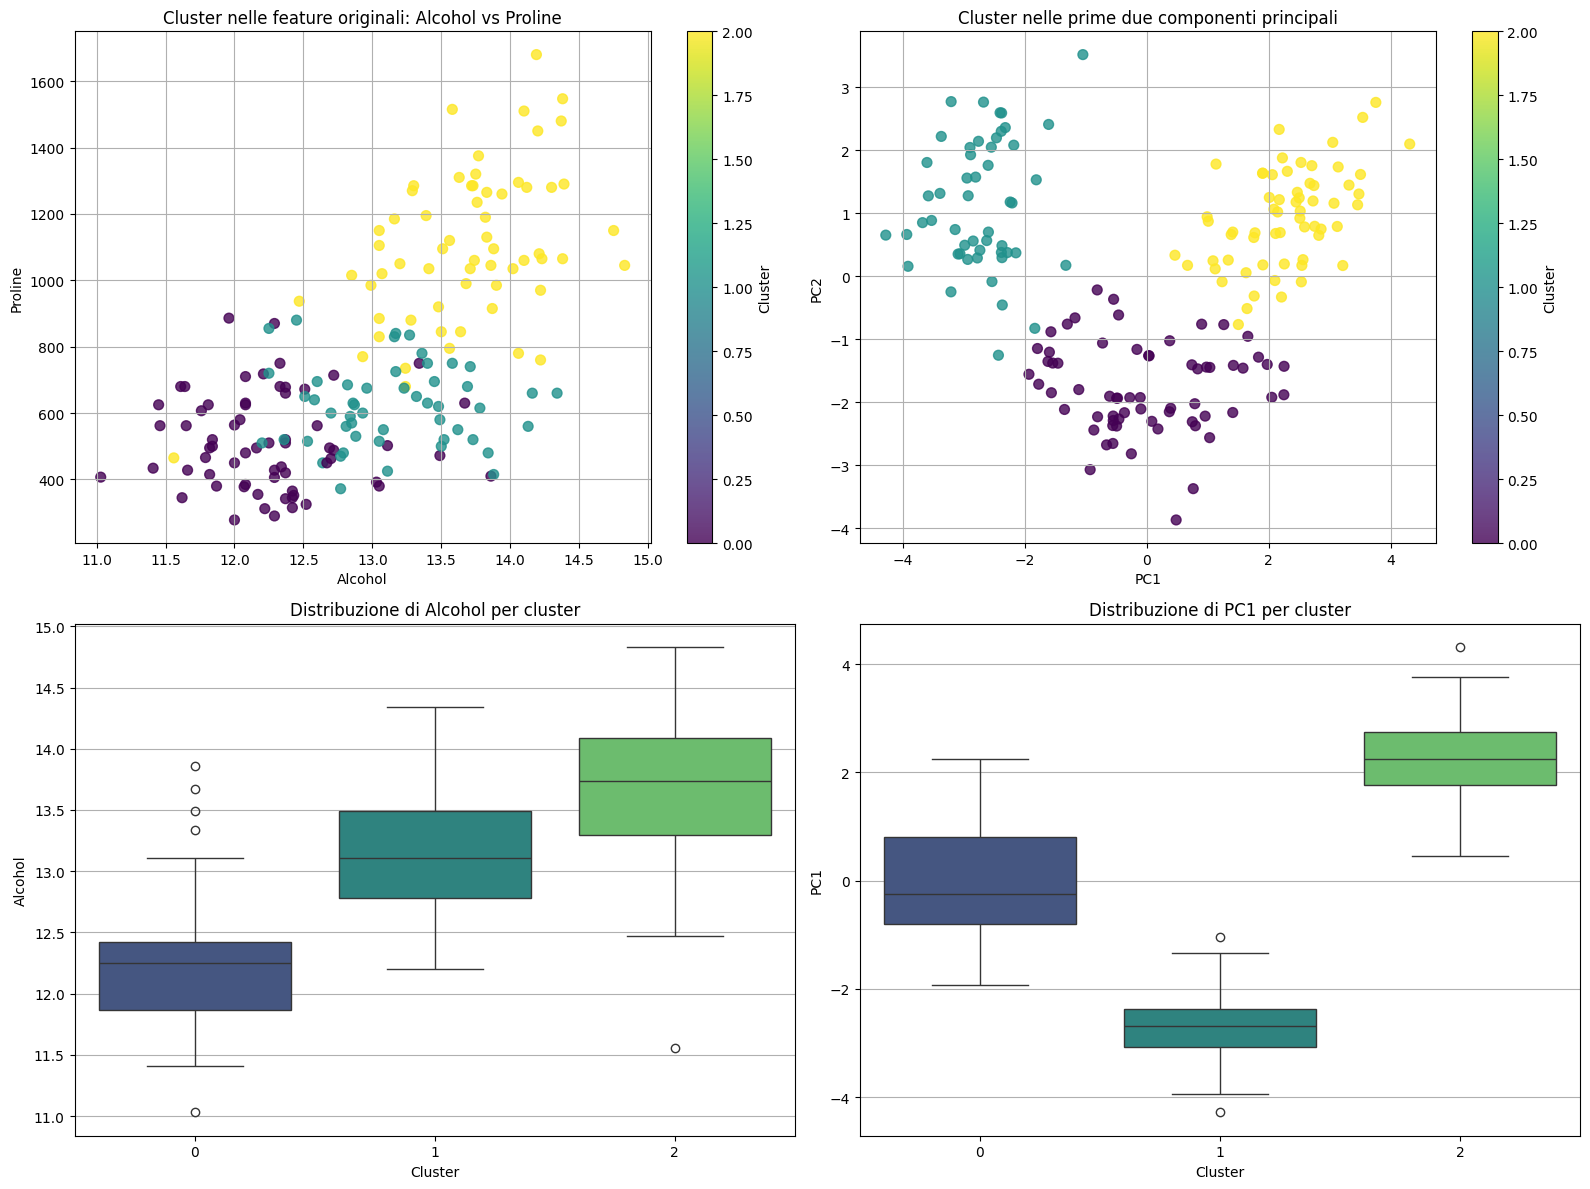

In [14]:
# Creazione di una visualizzazione multipla per confrontare feature originali e componenti principali
plt.figure(figsize=(16, 12))

# Feature originali significative (scegliamo due feature correlate con le prime PC)
feature1 = 'Alcohol'
feature2 = 'Proline' 

# Distribuzione nei cluster usando le feature originali
plt.subplot(2, 2, 1)
scatter_orig = plt.scatter(df[feature1], df[feature2], c=df['Cluster'], 
                          cmap='viridis', s=50, alpha=0.8)
plt.title(f'Cluster nelle feature originali: {feature1} vs {feature2}')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.grid(True)
plt.colorbar(scatter_orig, label='Cluster')

# Distribuzione nei cluster usando le prime due componenti principali
plt.subplot(2, 2, 2)
scatter_pc = plt.scatter(pc_df['PC1'], pc_df['PC2'], c=pc_df['Cluster'], 
                        cmap='viridis', s=50, alpha=0.8)
plt.title('Cluster nelle prime due componenti principali')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.colorbar(scatter_pc, label='Cluster')

# Distribuzione di una feature originale per cluster
plt.subplot(2, 2, 3)
sns.boxplot(x='Cluster', y=feature1, data=df, palette='viridis')
plt.title(f'Distribuzione di {feature1} per cluster')
plt.grid(True, axis='y')

# Distribuzione di PC1 per cluster
plt.subplot(2, 2, 4)
sns.boxplot(x='Cluster', y='PC1', data=pc_df, palette='viridis')
plt.title('Distribuzione di PC1 per cluster')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

### Interpretazione finale

La figura collega i cluster trovati con due viste diverse dei dati.

In alto a sinistra vediamo i cluster rispetto a due feature originali (`Alcohol` e `Proline`): il Cluster 2 tende ad avere valori più alti, mentre il Cluster 0 valori più bassi.

In alto a destra gli stessi cluster sono visualizzati nello spazio PCA: qui la separazione tra i gruppi risulta più chiara, perché PCA combina più feature in due componenti principali.

I boxplot in basso confermano questa lettura: `Alcohol` e soprattutto `PC1` assumono distribuzioni diverse nei tre cluster.

Il messaggio finale è che i cluster non vanno solo calcolati, ma anche interpretati: PCA aiuta a visualizzarli, mentre le feature originali aiutano a capire quali variabili li caratterizzano.